## Introduccion idk

Los procesos tienen las siguientes variables:

- Burst Time (Tiempo de Ejecucion):
Tiempo total que el proceso ocupa en la CPU para completar su ejecucion.

- Arrival Time (Tiempo de Llegada):
Tiempo en el que el proceso entra al sistema.

- Remaining Time (Tiempo Restante):
Tiempo que le falta al proceso para terminar su ejecucion.

- Completion Time (Tiempo de Completacion):
Tiempo en el que el proceso termino su ejecucion.

- Turnaround Time (Tiempo total en el sistema):
Tiempo total desde que el proceso llego, hasta que terminó.

- Waiting Time (Tiempo de espera):
Tiempo que el proceso paso en la cola de listos esperando su turno en la CPU.

## Resultados

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results/scheduler_data.csv")
#print(df)

In [73]:
# Tablas de promedios
average_completion = df.groupby("Algorithm")["CompletionTime"].mean()
average_wait = df.groupby("Algorithm")["WaitingTime"].mean()
average_turnaround = df.groupby("Algorithm")["TurnaroundTime"].mean()
average_response = df.groupby("Algorithm")["ResponseTime"].mean()
print(average_completion)
print(average_wait)
print(average_turnaround)
print(average_response)


Algorithm
CFS            62.2
FCFS           80.4
MLQ           108.4
Priority      110.7
RR             64.1
RRDynamic      72.9
RRDynamic2     64.0
SJF            41.6
SRTF           41.1
Name: CompletionTime, dtype: float64
Algorithm
CFS           41.7
FCFS          59.9
MLQ           87.9
Priority      90.2
RR            43.6
RRDynamic     52.4
RRDynamic2    43.5
SJF           21.1
SRTF          20.6
Name: WaitingTime, dtype: float64
Algorithm
CFS            55.3
FCFS           73.5
MLQ           101.5
Priority      103.8
RR             57.2
RRDynamic      66.0
RRDynamic2     57.1
SJF            34.7
SRTF           34.2
Name: TurnaroundTime, dtype: float64
Algorithm
CFS           15.1
FCFS          59.9
MLQ           71.4
Priority      69.4
RR             4.6
RRDynamic     29.3
RRDynamic2    10.8
SJF           21.1
SRTF          20.3
Name: ResponseTime, dtype: float64


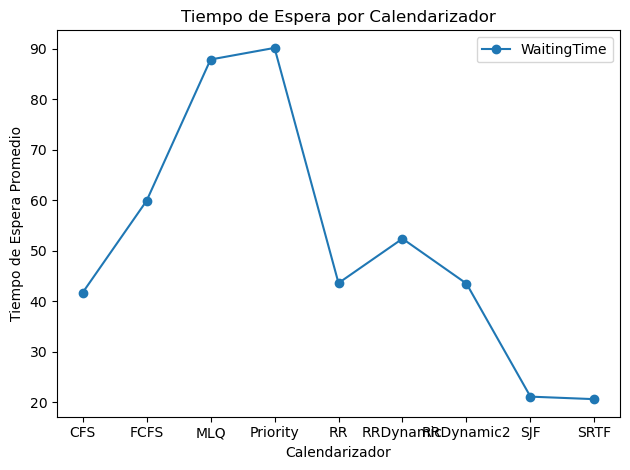

In [74]:
# Average waiting time per algorithm
avg_df = df.groupby("Algorithm")["WaitingTime"].mean().reset_index()

# plot
avg_df.plot(x="Algorithm", y="WaitingTime", kind="line", marker="o")
#plt.xticks(rotation=45)
plt.xlabel("Calendarizador")
plt.ylabel("Tiempo de Espera Promedio")
plt.title("Tiempo de Espera por Calendarizador")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

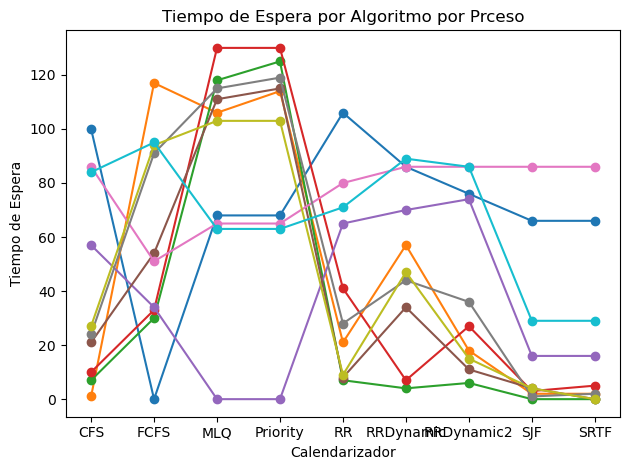

In [75]:
pivot = df.pivot(index="Algorithm", columns="PID", values="WaitingTime")

plt.figure(figsize=(10,5))
ax = pivot.plot(marker="o", legend=False)
#plt.xticks(rotation=45)
plt.xlabel("Calendarizador")
plt.ylabel("Tiempo de Espera")
plt.title("Tiempo de Espera por Algoritmo por Prceso")
plt.tight_layout()
plt.show()

In [76]:
result = df.groupby("Algorithm")["WaitingTime"].agg(
    Mean="mean",
    StdDev_Pop=lambda x: x.std(ddof=0)
)
print(result)


def gini(arr):
    """Compute Gini coefficient for a numpy array."""
    arr = np.array(arr, dtype=float)
    if np.amin(arr) < 0:
        arr -= np.amin(arr)
    arr += 1e-9  # avoid division by zero
    arr = np.sort(arr)
    n = arr.size
    index = np.arange(1, n+1)
    return (np.sum((2*index - n - 1) * arr)) / (n * np.sum(arr))

# Compute Gini per algorithm
gini_results = df.groupby("Algorithm")["WaitingTime"].apply(lambda x: gini(x.values))

print(gini_results)

            Mean  StdDev_Pop
Algorithm                   
CFS         41.7   34.940092
FCFS        59.9   35.514645
MLQ         87.9   37.106468
Priority    90.2   38.695736
RR          43.6   33.154788
RRDynamic   52.4   29.614861
RRDynamic2  43.5   31.388692
SJF         21.1   29.056669
SRTF        20.6   29.391155
Algorithm
CFS           0.461631
FCFS          0.331720
MLQ           0.220364
Priority      0.224612
RR            0.424312
RRDynamic     0.317939
RRDynamic2    0.397011
SJF           0.664929
SRTF          0.692233
Name: WaitingTime, dtype: float64


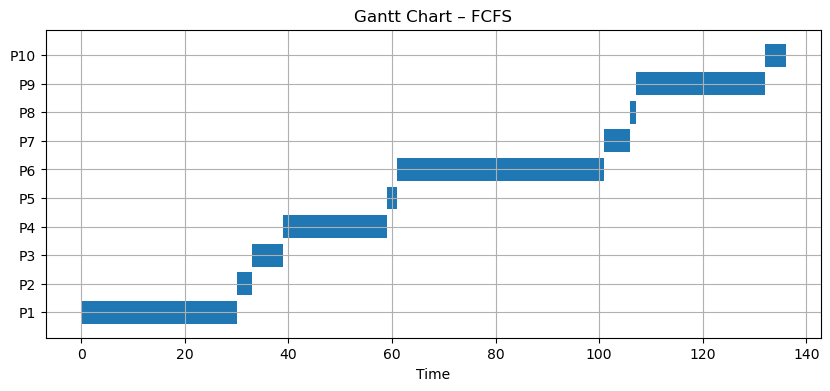

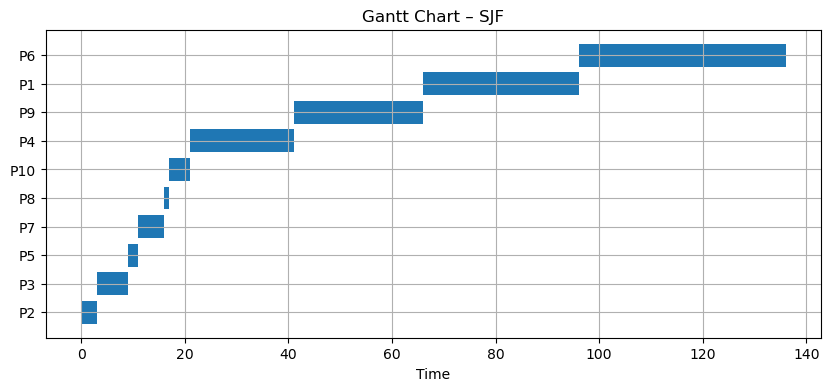

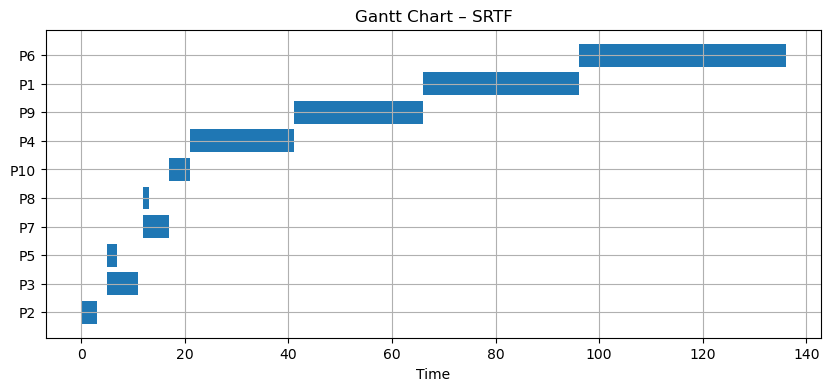

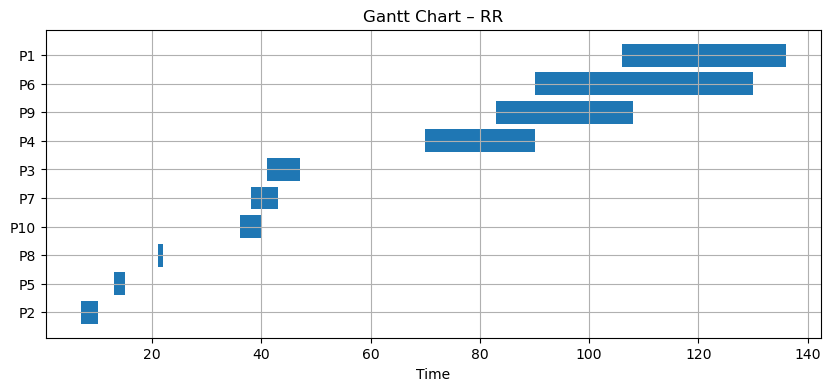

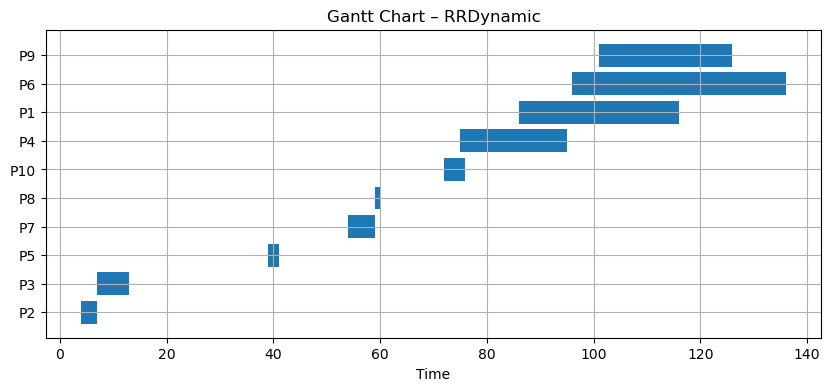

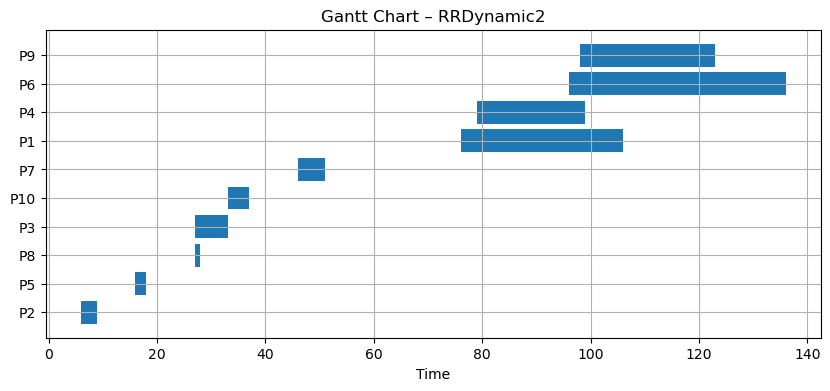

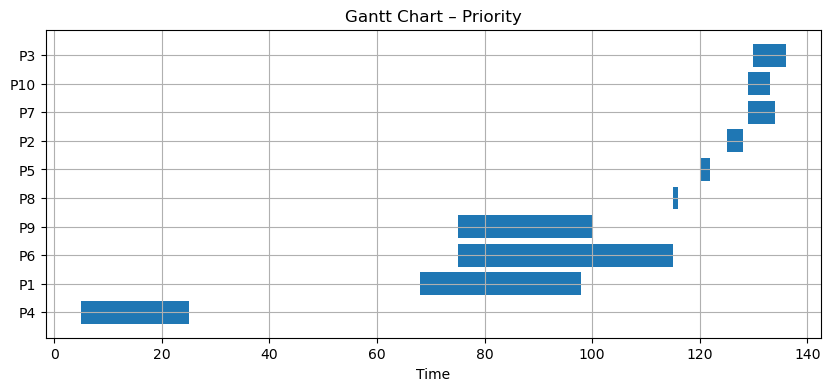

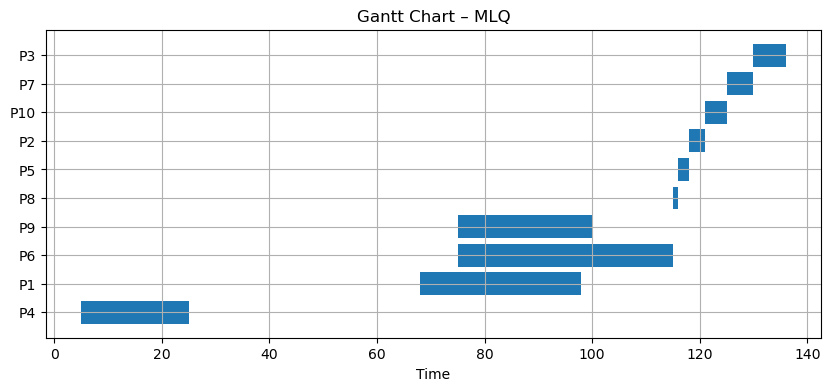

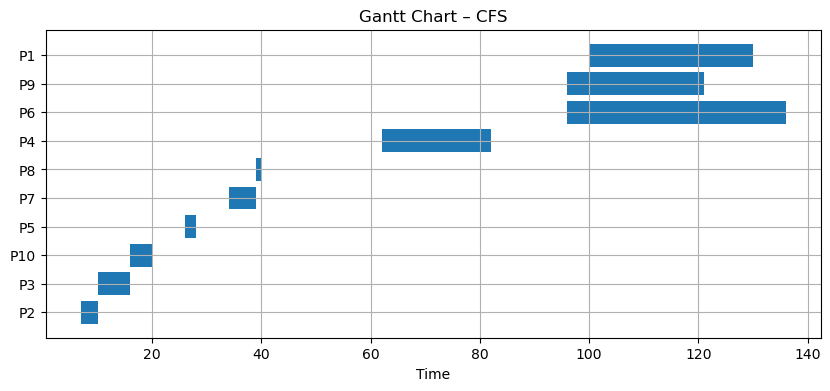

In [77]:
# Compute start times
df["StartTime"] = df["CompletionTime"] - df["BurstTime"]

# Plot Gantt per algorithm
algos = df["Algorithm"].unique()

for algo in algos:
    subset = df[df["Algorithm"] == algo].sort_values("StartTime")
    
    fig, ax = plt.subplots(figsize=(10, 4))
    yticks = []
    ylabels = []
    
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.broken_barh([(row["StartTime"], row["BurstTime"])], (i - 0.4, 0.8))
        yticks.append(i)
        ylabels.append(row["PID"])
    
    ax.set_title(f"Gantt Chart – {algo}")
    ax.set_xlabel("Time")
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.grid(True)

plt.show()

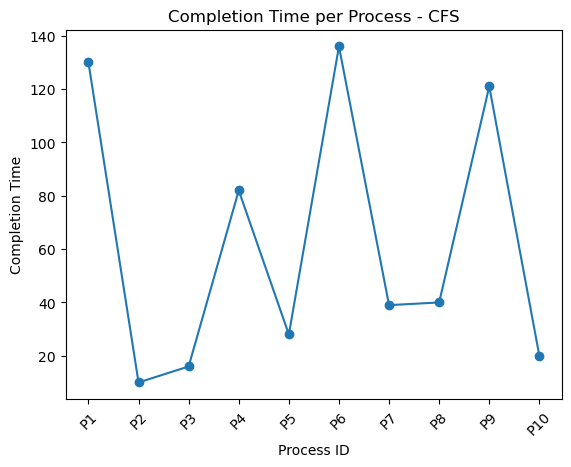

In [78]:
cfs = df[df["Algorithm"] == "CFS"]

plt.figure()
plt.plot(cfs["PID"], cfs["CompletionTime"], marker='o')
plt.xlabel("Process ID")
plt.ylabel("Completion Time")
plt.title("Completion Time per Process - CFS")
plt.xticks(rotation=45)

plt.show()

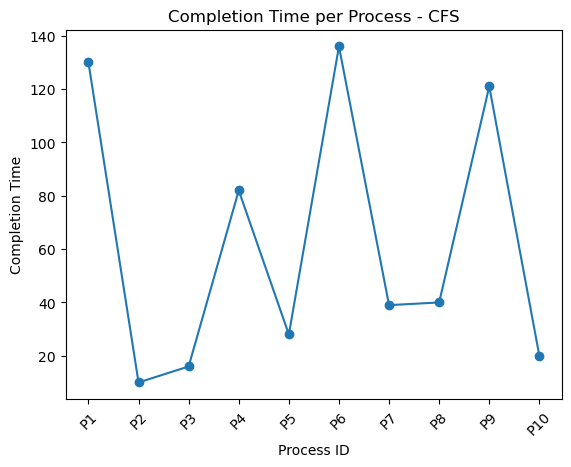

In [79]:
plt.figure()
plt.plot(cfs["PID"], cfs["CompletionTime"], marker='o')
plt.xlabel("Process ID")
plt.ylabel("Completion Time")
plt.title("Completion Time per Process - CFS")
plt.xticks(rotation=45)

plt.show()

            Fairness1  Fairness2  Fairness3  Fairness4  Fairness5
Algorithm                                                        
CFS          8.947333   0.207503   0.414286   6.824333   4.887000
FCFS        22.195500   0.228789   0.475472  20.072500  19.072500
MLQ         30.664167   0.186889   0.751351  28.541167  27.000000
Priority    31.377500   0.186391   0.772072  29.254500  26.631667
RR           7.587000   0.180471   0.429365   5.464000   1.445167
RRDynamic   13.285667   0.205461   0.510853  11.162667   9.329500
RRDynamic2   8.175333   0.185053   0.433071   6.052333   3.261500
SJF          4.474000   0.388349   0.290226   2.351000   1.351000
SRTF         3.927333   0.386590   0.286466   1.804333   0.751000


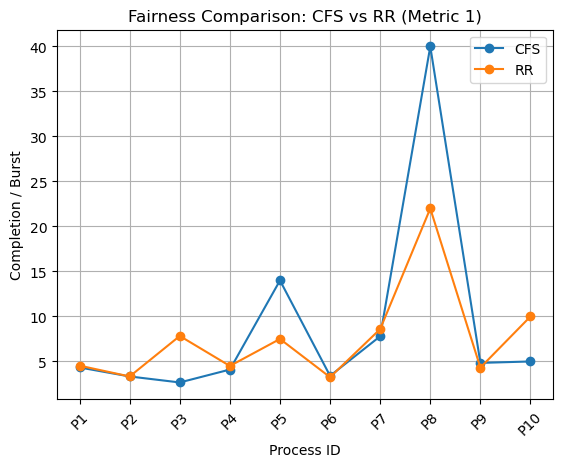

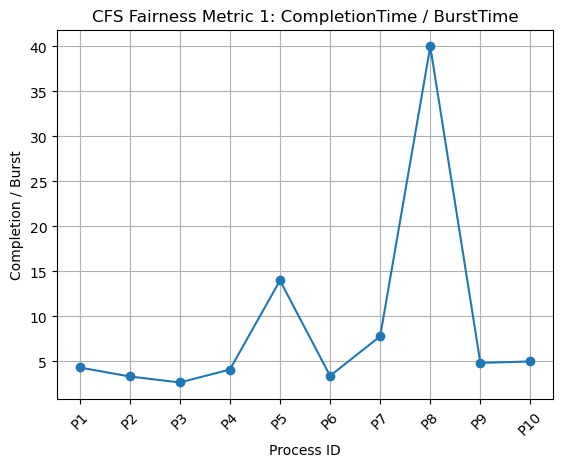

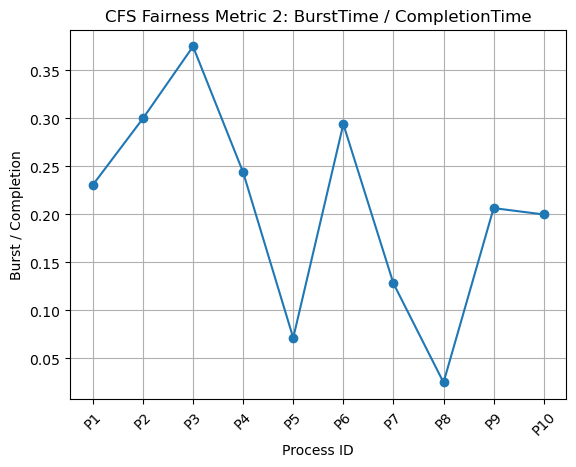

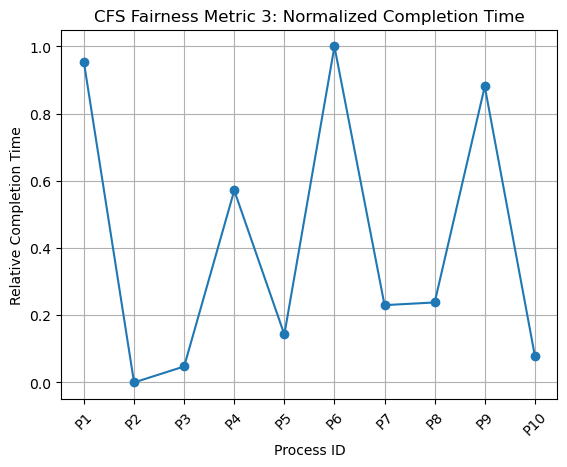

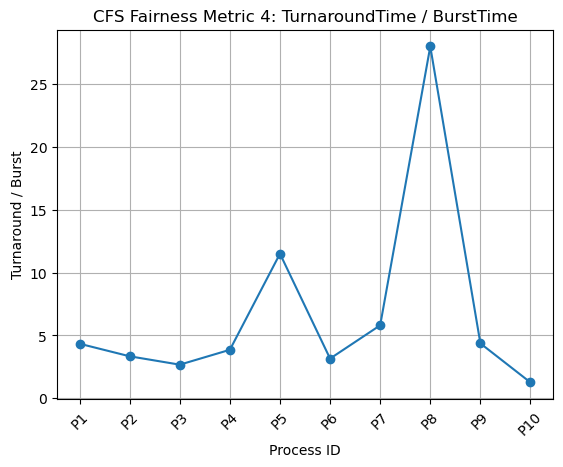

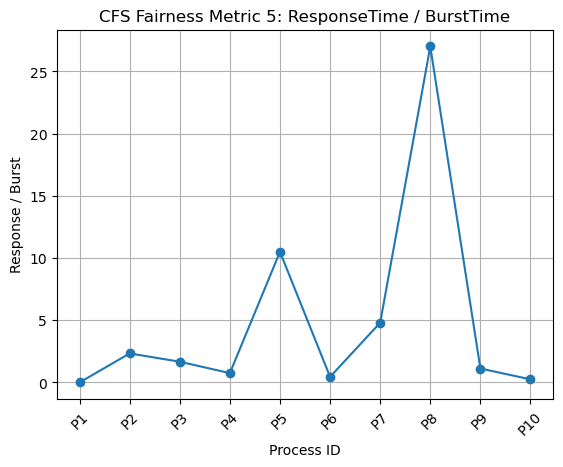

In [81]:
cfs = df[df["Algorithm"] == "CFS"].copy()

# Compute fairness metrics
cfs["Fairness1"] = cfs["CompletionTime"] / cfs["BurstTime"]
cfs["Fairness2"] = cfs["BurstTime"] / cfs["CompletionTime"]
cfs["Fairness3"] = (cfs["CompletionTime"] - cfs["CompletionTime"].min()) / (cfs["CompletionTime"].max() - cfs["CompletionTime"].min())

cfs["Fairness4"] = cfs["TurnaroundTime"] / cfs["BurstTime"]
cfs["Fairness5"] = cfs["ResponseTime"] / cfs["BurstTime"]

# Make a copy to avoid warnings
df2 = df.copy()

# Compute fairness metrics for ALL algorithms
df2["Fairness1"] = df2["CompletionTime"] / df2["BurstTime"]
df2["Fairness2"] = df2["BurstTime"] / df2["CompletionTime"]
df2["Fairness3"] = (df2["CompletionTime"] - df2.groupby("Algorithm")["CompletionTime"].transform("min")) / \
                   (df2.groupby("Algorithm")["CompletionTime"].transform("max") - df2.groupby("Algorithm")["CompletionTime"].transform("min"))

df2["Fairness4"] = df2["TurnaroundTime"] / df2["BurstTime"]
df2["Fairness5"] = df2["ResponseTime"] / df2["BurstTime"]

# Compute mean fairness metrics per algorithm
fairness_means = df2.groupby("Algorithm")[["Fairness1","Fairness2","Fairness3","Fairness4","Fairness5"]].mean()

print(fairness_means)


algos = ["CFS", "RR"]
metric = "Fairness1"

plt.figure()

for algo in algos:
    subset = df[df["Algorithm"] == algo].copy()
    subset["Fairness1"] = subset["CompletionTime"] / subset["BurstTime"]
    plt.plot(subset["PID"], subset["Fairness1"], marker="o", label=algo)

plt.xlabel("Process ID")
plt.ylabel("Completion / Burst")
plt.title("Fairness Comparison: CFS vs RR (Metric 1)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()


# Plot 1: CompletionTime / BurstTime
plt.figure()
plt.plot(cfs["PID"], cfs["Fairness1"], marker="o")
plt.xlabel("Process ID")
plt.ylabel("Completion / Burst")
plt.title("CFS Fairness Metric 1: CompletionTime / BurstTime")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot 2: BurstTime / CompletionTime
plt.figure()
plt.plot(cfs["PID"], cfs["Fairness2"], marker="o")
plt.xlabel("Process ID")
plt.ylabel("Burst / Completion")
plt.title("CFS Fairness Metric 2: BurstTime / CompletionTime")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot 3: Relative Completion Time
plt.figure()
plt.plot(cfs["PID"], cfs["Fairness3"], marker="o")
plt.xlabel("Process ID")
plt.ylabel("Relative Completion Time")
plt.title("CFS Fairness Metric 3: Normalized Completion Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot 4: TurnaroundTime / BurstTime
plt.figure()
plt.plot(cfs["PID"], cfs["Fairness4"], marker="o")
plt.xlabel("Process ID")
plt.ylabel("Turnaround / Burst")
plt.title("CFS Fairness Metric 4: TurnaroundTime / BurstTime")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot 5: ResponseTime / BurstTime
plt.figure()
plt.plot(cfs["PID"], cfs["Fairness5"], marker="o")
plt.xlabel("Process ID")
plt.ylabel("Response / Burst")
plt.title("CFS Fairness Metric 5: ResponseTime / BurstTime")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()